In [26]:
import polars as pl
import numpy as np
import re
from datetime import date

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(100)

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [27]:
#  loading data for modeling
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")


Tech table shape: (24048, 225)


In [28]:
df_tech['target_return'].describe([0.01, 0.05, 0.1, 0.25, 0.5, 0.7, 0.75, 0.9, 0.95, 0.99])

statistic,value
str,f64
"""count""",24048.0
"""null_count""",0.0
"""mean""",0.042991
"""std""",0.045487
"""min""",-0.131541
"""1%""",-0.007509
"""5%""",0.000683
"""10%""",0.00506
"""25%""",0.014795


In [29]:
df_tech

symbol,earnings_date,entry_price,target_return,target_direction,max_high,min_high,max_day,min_day,open_pct_t-10,high_pct_t-10,low_pct_t-10,volume_rel_t-10,rsi_t-10,macd_t-10,macd_hist_t-10,roc_t-10,ema50_pct_t-10,ema200_pct_t-10,ema50_200_pct_t-10,adx_t-10,atr_t-10,bb_width_t-10,bb_pct_b_t-10,sigma_t-10,obv_zscore_t-10,vwap_pct_t-10,open_pct_t-9,high_pct_t-9,low_pct_t-9,volume_rel_t-9,rsi_t-9,macd_t-9,macd_hist_t-9,roc_t-9,ema50_pct_t-9,ema200_pct_t-9,ema50_200_pct_t-9,adx_t-9,atr_t-9,bb_width_t-9,bb_pct_b_t-9,sigma_t-9,obv_zscore_t-9,vwap_pct_t-9,open_pct_t-8,high_pct_t-8,low_pct_t-8,volume_rel_t-8,rsi_t-8,…,rsi_t-1,macd_t-1,macd_hist_t-1,roc_t-1,ema50_pct_t-1,ema200_pct_t-1,ema50_200_pct_t-1,adx_t-1,atr_t-1,bb_width_t-1,bb_pct_b_t-1,sigma_t-1,obv_zscore_t-1,vwap_pct_t-1,open_pct_t0,high_pct_t0,low_pct_t0,volume_rel_t0,rsi_t0,macd_t0,macd_hist_t0,roc_t0,ema50_pct_t0,ema200_pct_t0,ema50_200_pct_t0,adx_t0,atr_t0,bb_width_t0,bb_pct_b_t0,sigma_t0,obv_zscore_t0,vwap_pct_t0,open_pct_t+1,high_pct_t+1,low_pct_t+1,volume_rel_t+1,rsi_t+1,macd_t+1,macd_hist_t+1,roc_t+1,ema50_pct_t+1,ema200_pct_t+1,ema50_200_pct_t+1,adx_t+1,atr_t+1,bb_width_t+1,bb_pct_b_t+1,sigma_t+1,obv_zscore_t+1,vwap_pct_t+1
str,date,f64,f64,i64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ES""",2026-05-06,66.253525,0.04885,1,69.489998,67.301083,10,3,0.006562,0.016107,-0.00343,-0.305777,36.272317,-0.010756,-0.002239,-4.145801,-0.037609,-0.005236,0.033638,14.990857,0.021691,0.057975,0.009755,0.009444,0.762511,-0.025519,-0.017159,0.001163,-0.017159,-0.280529,47.305384,-0.009453,-0.000919,-2.550661,-0.012421,0.020076,0.032906,14.645093,0.021507,0.057628,0.45183,0.011933,0.798064,-0.002748,0.004225,0.008158,-0.007721,-0.161145,46.648042,…,47.62827,-0.00115,0.002946,3.112847,-0.009568,0.01975,0.029601,12.772188,0.021316,0.063213,0.504101,0.014357,0.853309,-0.005775,0.002773,0.011092,-0.002335,0.026343,45.715087,-0.001904,0.001772,2.192377,-0.01445,0.013983,0.02885,11.862879,0.020862,0.063278,0.42768,0.014334,0.788507,-0.010099,0.009696,0.013723,-0.008502,0.862451,39.123605,-0.004283,-0.000421,-2.515627,-0.034384,-0.007841,0.027489,12.413609,0.021984,0.068389,0.151429,0.015305,0.67003,-0.02737
"""ES""",2021-02-16,66.493126,0.00583,0,66.880754,65.209135,2,5,0.002733,0.01025,-0.008542,-0.469426,49.792646,0.004894,-0.001176,-0.869372,0.002308,0.024834,0.022474,18.828985,0.023559,0.050484,0.323677,0.012768,-0.916419,-0.006003,-0.00204,0.010767,-0.011447,-0.374694,51.451584,0.004443,-0.001278,1.250877,0.006932,0.029547,0.02246,18.256259,0.023356,0.049371,0.438533,0.012817,-0.807811,-0.00337,-0.000114,0.005341,-0.006364,-0.51327,50.490645,…,41.184722,-0.004428,-0.00431,-2.662858,-0.025094,-0.007079,0.018479,15.97327,0.022123,0.061311,0.064511,0.011278,-1.039334,-0.028668,0.018477,0.018477,-0.005245,-0.059354,37.256298,-0.00705,-0.005544,-4.45329,-0.038247,-0.021788,0.017114,16.840145,0.02255,0.067256,-0.044324,0.011626,-1.180804,-0.040561,0.019918,0.027204,-0.010809,0.268404,33.134587,-0.010641,-0.007285,-6.675745,-0.053939,-0.039481,0.015282,18.433549,0.024049,0.085146,-0.082339,0.011866,-1.377774,-0.055005
"""ES""",2015-07-30,33.915607,0.028761,0,34.891054,33.799636,9,4,-0.012836,0.00207,-0.014907,-0.491236,63.208251,0.002605,0.005899,5.990754,0.018779,0.003655,-0.014845,12.883201,0.016828,0.071787,0.977696,0.009777,0.561847,0.036924,0.00793,0.011895,-0.001461,-0.409102,58.737759,0.003803,0.005698,3.031573,0.010337,-0.004199,-0.014388,13.244633,0.016704,0.074163,0.811948,0.010083,0.484919,0.028456,0.005675,0.006515,-0.007776,-0.394864,54.990125,…,60.220574,0.005924,0.00227,1.194449,0.016307,0.004125,-0.011987,11.68533,0.015847,0.036096,0.878829

In [30]:

fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund = pl.read_parquet(fund_path)
df_fund = df_fund.select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin", "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq",
    "roe", "roe_qoq"
])

df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob"
])

df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])

df_model = df_tech.join(df_fund, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left", suffix="_fb")
df_model = df_model.join(df_nz, on=["symbol", "earnings_date"], how="left", suffix="_nz")

df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector = df_sector_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")
df_model = df_model.join(df_sector, on="symbol", how="left")

print(f"Final shape: {df_model.shape}")

Final shape: (24048, 253)


In [31]:
# ---- Parse features into time-varying and static ----
feature_cols = [c for c in df_model.columns
                if c not in ["symbol", "earnings_date", "target_return",
                "entry_price", "target_direction", "max_high",
                "min_high", "max_day", "min_day"]]

time_cols = [c for c in feature_cols if re.match(r".+_t[+-]?\d+$", c)]
static_cols = [c for c in feature_cols if c not in time_cols]

bases = sorted(set(re.sub(r"_t[+-]?\d+$", "", c) for c in time_cols))
steps = sorted({int(re.search(r"_t([+-]?\d+)$", c).group(1)) for c in time_cols})
n_steps, n_bases, n_static = len(steps), len(bases), len(static_cols)
print(f"Time steps: {steps},  bases: {n_bases},  static: {n_static}")

col_to_idx = {c: i for i, c in enumerate(feature_cols)}
step_to_idx = {s: i for i, s in enumerate(steps)}
base_to_idx = {b: i for i, b in enumerate(bases)}
col_grid = np.full((n_steps, n_bases), -1, dtype=int)
for c in time_cols:
    s = int(re.search(r"_t([+-]?\d+)$", c).group(1))
    b = re.sub(r"_t[+-]?\d+$", "", c)
    col_grid[step_to_idx[s], base_to_idx[b]] = col_to_idx[c]

Time steps: [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1],  bases: 18,  static: 28


In [32]:
# ---- PyTorch models ----
class LSTM(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat):
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(1)


class BiLSTM(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2 + n_static, 1)

    def forward(self, x_seq, x_stat):
        _, (hn, _) = self.lstm(x_seq)
        h = torch.cat((hn[-2], hn[-1]), dim=1)
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(1)


class CNN_LSTM(nn.Module):
    def __init__(self, n_bases, n_static, hidden=64, kernel=3):
        super().__init__()
        self.conv = nn.Conv1d(n_bases, n_bases, kernel, padding=kernel//2)
        self.lstm = nn.LSTM(n_bases, hidden, batch_first=True)
        self.fc = nn.Linear(hidden + n_static, 1)

    def forward(self, x_seq, x_stat):
        x_seq = self.conv(x_seq.transpose(1, 2)).transpose(1, 2)
        _, (hn, _) = self.lstm(x_seq)
        h = hn[-1]
        if x_stat is not None:
            h = torch.cat([h, x_stat], dim=1)
        return self.fc(h).squeeze(1)

In [33]:
# ---- Train / eval helpers ----
def train_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss, n = 0, 0
    for x_seq, x_stat, y in loader:
        x_seq, x_stat, y = x_seq.to(device), x_stat.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x_seq, x_stat if n_static > 0 else None), y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * len(y)
        n += len(y)
    return total_loss / n


def eval_model(model, loader):
    model.eval()
    preds, probs, trues = [], [], []
    with torch.no_grad():
        for x_seq, x_stat, y in loader:
            x_seq, x_stat = x_seq.to(device), x_stat.to(device)
            logits = model(x_seq, x_stat if n_static > 0 else None)
            prob = torch.sigmoid(logits)
            probs.append(prob.cpu().numpy())
            preds.append((prob >= 0.5).cpu().numpy())
            trues.append(y.numpy())
    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    trues = np.concatenate(trues)
    return {
        "preds": preds, "probs": probs, "true": trues,
        "acc": accuracy_score(trues, preds),
        "f1": f1_score(trues, preds),
        "auc": roc_auc_score(trues, probs),
    }

In [34]:
# ---- Temporal folds (same as b3) ----
Train_Window = 7
Folds = [
    (date(y - Train_Window, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

def reshape_features(df):
    X = df.select(feature_cols).to_numpy().astype(np.float32)

    # inf -> nan -> median impute
    X = np.where(np.isinf(X), np.nan, X)
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(X)

    X_time = np.zeros((X.shape[0], n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]

    X_static = X[:, [col_to_idx[c] for c in static_cols]] if n_static > 0 else None

    scaler = StandardScaler()
    X_time = scaler.fit_transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    if X_static is not None:
        s_scaler = StandardScaler()
        X_static = s_scaler.fit_transform(X_static)

    return X_time, X_static, imputer, scaler, s_scaler if n_static > 0 else None


def transform_test(df, imputer, scaler, s_scaler):
    X = df.select(feature_cols).to_numpy().astype(np.float32)
    X = np.where(np.isinf(X), np.nan, X)
    X = imputer.transform(X)
    X_time = np.zeros((X.shape[0], n_steps, n_bases), dtype=np.float32)
    for s in range(n_steps):
        for b in range(n_bases):
            idx = col_grid[s, b]
            if idx >= 0:
                X_time[:, s, b] = X[:, idx]
    X_time = scaler.transform(X_time.reshape(-1, n_bases)).reshape(X_time.shape)
    X_static = X[:, [col_to_idx[c] for c in static_cols]] if n_static > 0 else None
    if X_static is not None and s_scaler is not None:
        X_static = s_scaler.transform(X_static)
    return X_time, X_static


BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3

results = {}

for ModelClass, name in [(LSTM, "LSTM"), (BiLSTM, "BiLSTM"), (CNN_LSTM, "CNN-LSTM")]:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}

    for fold_num, (train_start, test_start, test_end) in enumerate(Folds, 1):
        train = df_model.filter(
            (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
        )
        test = df_model.filter(
            (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
        )

        X_train_t, X_train_s, imputer, scaler, s_scaler = reshape_features(train)
        X_test_t, X_test_s = transform_test(test, imputer, scaler, s_scaler)

        y_train = train["target_direction"].to_numpy().astype(np.float32)
        y_test = test["target_direction"].to_numpy().astype(np.float32)

        train_ds = TensorDataset(
            torch.tensor(X_train_t),
            torch.tensor(X_train_s) if X_train_s is not None else torch.zeros(len(X_train_t), 1),
            torch.tensor(y_train),
        )
        test_ds = TensorDataset(
            torch.tensor(X_test_t),
            torch.tensor(X_test_s) if X_test_s is not None else torch.zeros(len(X_test_t), 1),
            torch.tensor(y_test),
        )

        train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

        model = ModelClass(n_bases, n_static).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.BCEWithLogitsLoss()

        for epoch in range(EPOCHS):
            train_epoch(model, train_loader, opt, loss_fn)

        result = eval_model(model, test_loader)
        clf["fold_acc"].append(result["acc"])
        clf["preds"].extend(result["preds"])
        clf["probs"].extend(result["probs"])
        clf["true"].extend(result["true"])
        print(f"  Fold {fold_num} [{test_start.year}]: DA={result['acc']:.4f}")

    results[name] = clf


LSTM
  Fold 1 [2021]: DA=0.5736
  Fold 2 [2022]: DA=0.6091
  Fold 3 [2023]: DA=0.5685
  Fold 4 [2024]: DA=0.5405
  Fold 5 [2025]: DA=0.5657

BiLSTM
  Fold 1 [2021]: DA=0.5569
  Fold 2 [2022]: DA=0.5899
  Fold 3 [2023]: DA=0.5514
  Fold 4 [2024]: DA=0.5265
  Fold 5 [2025]: DA=0.5603

CNN-LSTM
  Fold 1 [2021]: DA=0.5741
  Fold 2 [2022]: DA=0.6142
  Fold 3 [2023]: DA=0.5650
  Fold 4 [2024]: DA=0.5340
  Fold 5 [2025]: DA=0.5603


In [35]:
# ---- Results summary ----
from sklearn.metrics import precision_score, recall_score

print("=== Direction (Classification) ===")
print(f"{'Model':<15} {'Avg DA%':>10} {'Pooled F1':>10} {'Pooled Prec':>12} {'Pooled Rec':>12} {'Pooled AUC':>10}")
print("-" * 65)
for name, r in results.items():
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    probs = np.array(r["probs"])
    print(f"{name:<15} {np.mean(r['fold_acc']):>10.4f} {f1_score(true, preds):>10.4f} "
          f"{precision_score(true, preds):>12.4f} {recall_score(true, preds):>12.4f} "
          f"{roc_auc_score(true, probs):>10.4f}")

=== Direction (Classification) ===
Model              Avg DA%  Pooled F1  Pooled Prec   Pooled Rec Pooled AUC
-----------------------------------------------------------------
LSTM                0.5715     0.6233       0.6238       0.6228     0.5805
BiLSTM              0.5570     0.6104       0.6111       0.6097     0.5639
CNN-LSTM            0.5695     0.6198       0.6231       0.6166     0.5900



**LSTM (Long Short-Term Memory)** — Processes the 20 time steps (`t-10` to `t+1`→`t+9`) in order. At each step, an LSTM cell decides what to remember/forget via gates. The final hidden state becomes a summary of the entire 20-step sequence, which is concatenated with static features (fundamentals, sentiment, sector) and passed through a linear layer to predict `target_class`.

**BiLSTM (Bidirectional LSTM)** — Two LSTMs run in parallel: one forward (`t-10` → `t+9`), one backward (`t+9` → `t-10`). Their final hidden states are concatenated, giving the model access to both past and future context at each point in the sequence. This captures patterns like "leading up to earnings and right after" jointly.

**CNN-LSTM** — A 1D Conv layer slides a kernel (window size 3) over the time dimension *before* the LSTM. This acts as a feature extractor — it learns local temporal patterns (e.g., "RSI and MACD both spiked together") and passes the filtered representations to the LSTM. The conv layer reduces noise and extracts higher-level time-local features.

**Why reshape by column names?** The features from the pipeline already encode time in their names (`rsi_t-10`, `rsi_t-9`, ..., `rsi_t+1`, `rsi_t+9`). Rather than treating them as 220 independent columns, we parse the `_t+/-N` suffix to group them into a true sequence tensor of shape `(samples, 20 time steps, 11 base indicators)`. This lets the LSTM exploit the temporal order.

**Static features** (fundamentals, sentiment scores, sector dummies) don't have a time dimension, so they're concatenated after the LSTM reduces the sequence to a single vector.

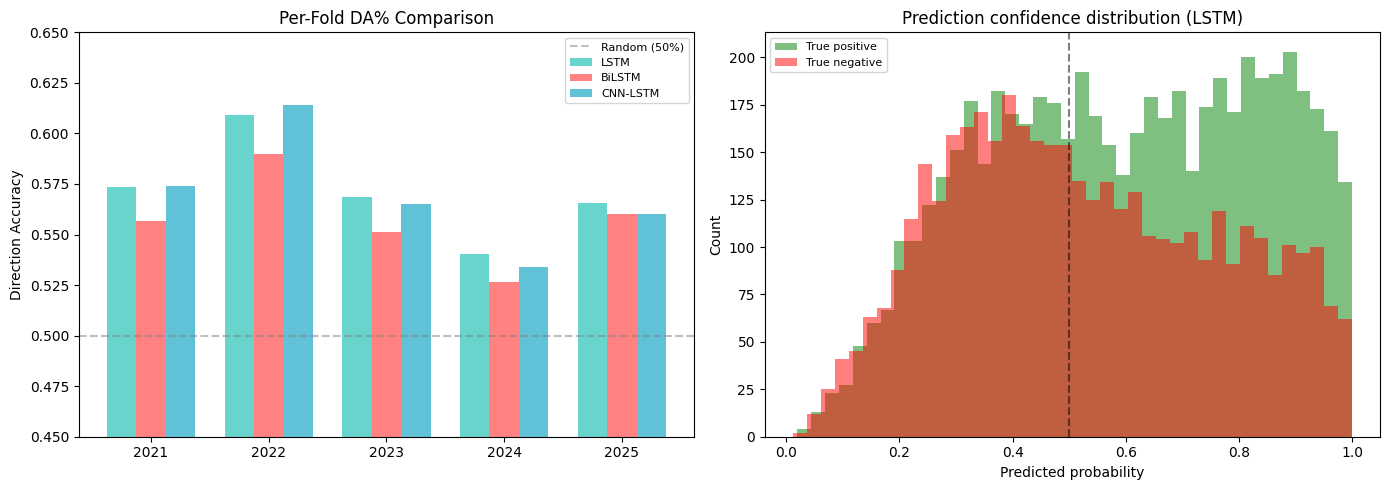

In [36]:
# ---- Visualization: per-fold accuracy comparison ----
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: per-fold DA%
fold_years = [2021, 2022, 2023, 2024, 2025]
x = np.arange(len(fold_years))
bar_width = 0.25
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']
for i, (name, r) in enumerate(results.items()):
    axes[0].bar(x + i*bar_width, r['fold_acc'], bar_width,
                label=name, color=colors[i], alpha=0.85)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5, label='Random (50%)')
axes[0].set_xticks(x + bar_width)
axes[0].set_xticklabels(fold_years)
axes[0].set_ylabel('Direction Accuracy')
axes[0].set_title('Per-Fold DA% Comparison')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.45, 0.65)

# Probability distribution of correct vs incorrect predictions (pooled)
best_name = max(results, key=lambda n: np.mean(results[n]['fold_acc']))
best = results[best_name]
true, probs = np.array(best['true']), np.array(best['probs'])
axes[1].hist(probs[true == 1], bins=40, alpha=0.5, label='True positive', color='green')
axes[1].hist(probs[true == 0], bins=40, alpha=0.5, label='True negative', color='red')
axes[1].axvline(0.5, color='black', ls='--', alpha=0.5)
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Prediction confidence distribution ({best_name})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

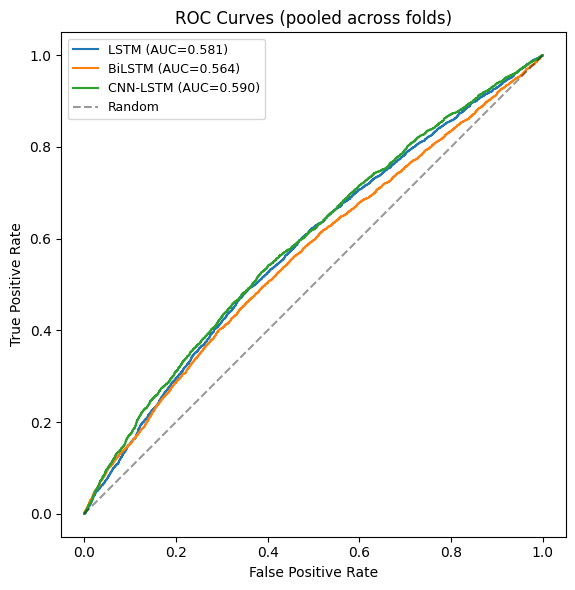

In [37]:
# ---- ROC curves for all models (pooled across folds) ----
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['true'], r['probs'])
    auc = roc_auc_score(r['true'], r['probs'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (pooled across folds)')
ax.legend(fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()